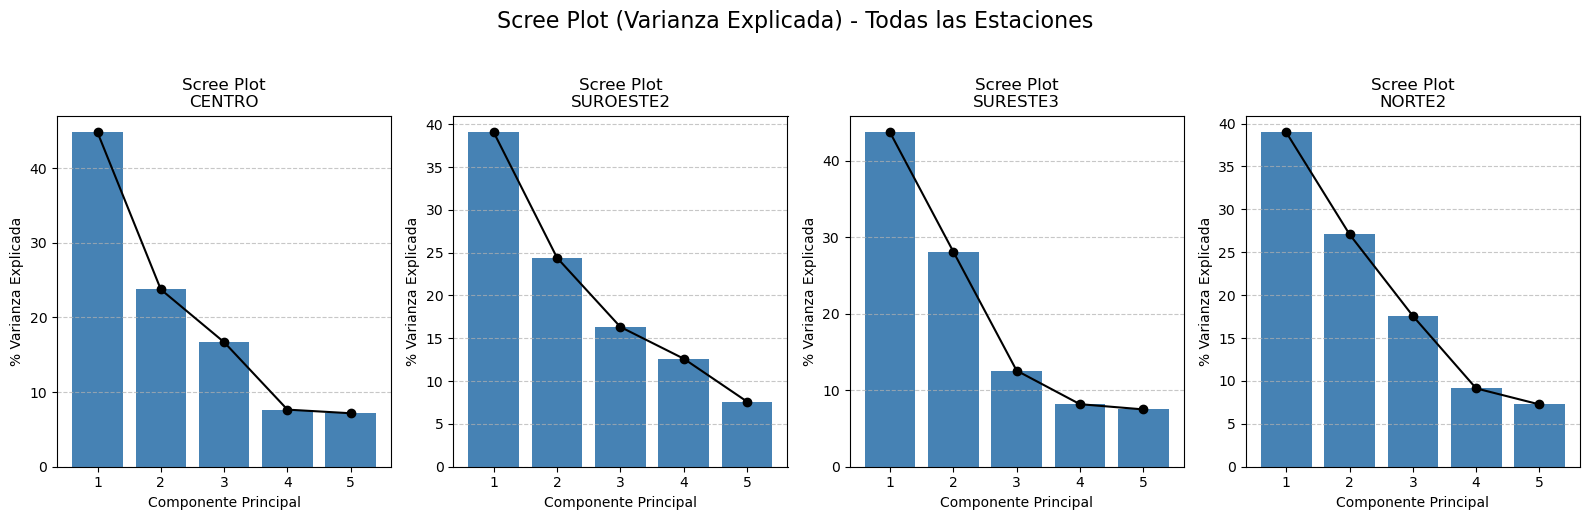

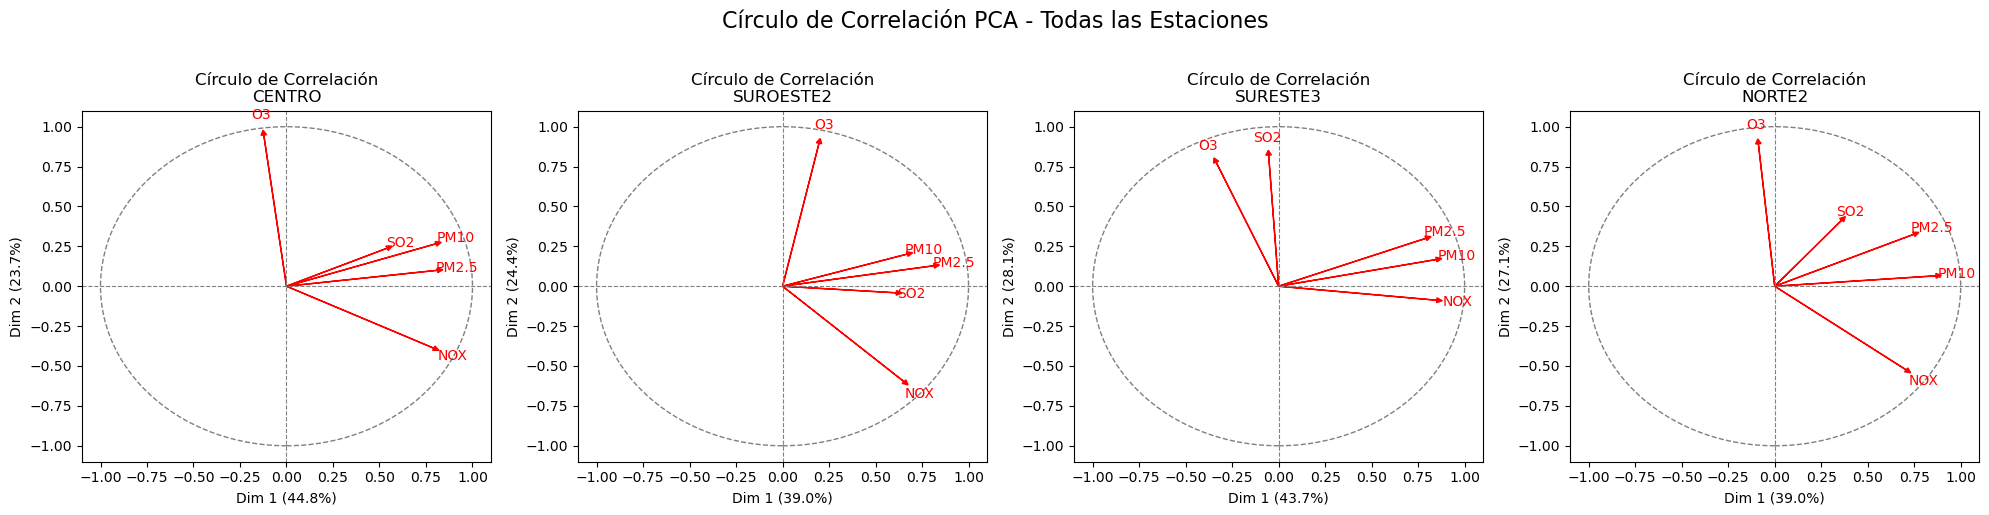

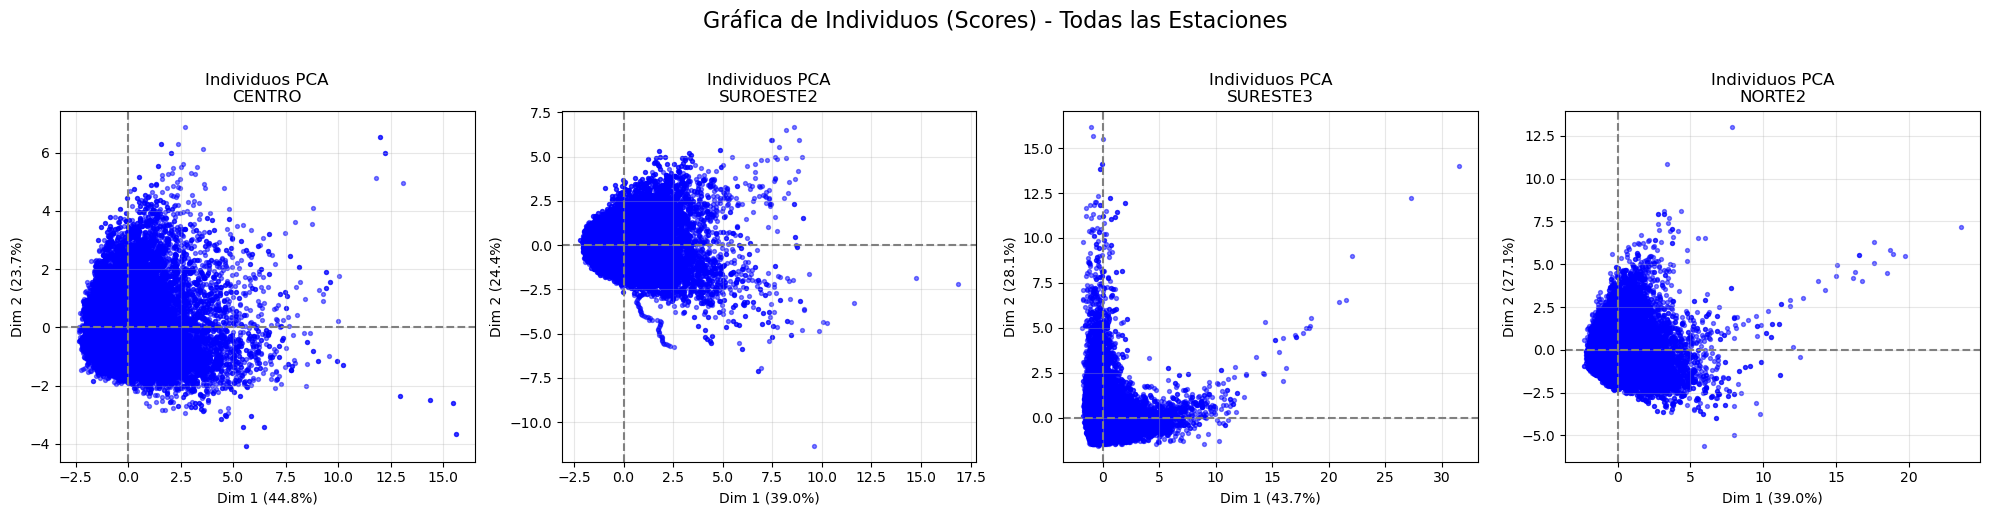

/var/folders/55/s6djj0fs7sz4wgdg619m7gy40000gn/T/ipykernel_67421/2099091471.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(res["features"][indices_orden], rotation=45, ha="right")
/var/folders/55/s6djj0fs7sz4wgdg619m7gy40000gn/T/ipykernel_67421/2099091471.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(res["features"][indices_orden], rotation=45, ha="right")
/var/folders/55/s6djj0fs7sz4wgdg619m7gy40000gn/T/ipykernel_67421/2099091471.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(res["features"][indices_orden], rotation=45, ha="right")
/var/folders/55/s6djj0fs7sz4wgdg619m7gy40000gn/T/ipykernel_67421/2099091471.py:124: UserWarning: set_ticklabels() should only be u

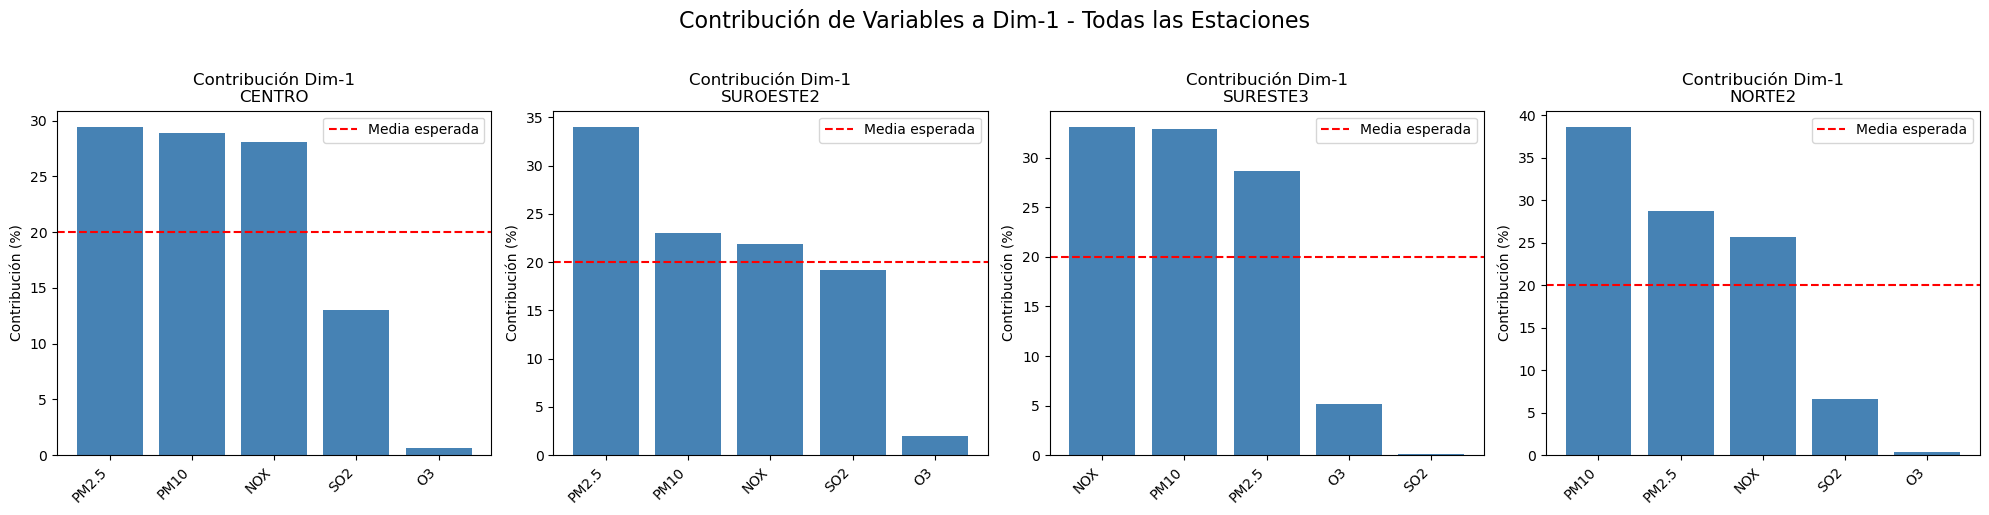

In [72]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ===============================
# Definiciones de parámetros
# ===============================
# Listado de archivos y sus nombres de estación para automatizar
estaciones = [
    {"nombre": "CENTRO", "archivo": "df_CENTRO_22_25.csv"},
    {"nombre": "SUROESTE2", "archivo": "df_SUROESTE2_22_25.csv"},
    {"nombre": "SURESTE3", "archivo": "df_SURESTE3_22_25.csv"},
    {"nombre": "NORTE2", "archivo": "df_NORTE2_22_25.csv"}
]
cols_contaminantes = ["PM10", "PM2.5", "O3", "NOX", "SO2"]

# ========================
# Realizar PCA para todos
# ========================
pca_results = []  # Lista para guardar resultados de cada estación

for est in estaciones:
    df = pd.read_csv(est["archivo"])
    datos = df[cols_contaminantes]

    # Escalamiento y PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(datos)
    pca = PCA()
    pca.fit(X_scaled)
    pca_ind = pca.transform(X_scaled)
    varianza_expl = pca.explained_variance_ratio_ * 100
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    features = datos.columns
    
    contribs = 100 * (loadings[:, 0] ** 2) / np.sum(loadings[:, 0] ** 2)
    indices_ordenados = np.argsort(contribs)[::-1]
    
    pca_results.append({
        "nombre": est["nombre"],
        "varianza_expl": varianza_expl,
        "loadings": loadings,
        "features": features,
        "pca_ind": pca_ind,
        "contribs": contribs,
        "indices_ordenados": indices_ordenados
    })

# =========================================
# Graficar todos los scree plots juntos
# =========================================
fig, axes = plt.subplots(1, len(pca_results), figsize=(4*len(pca_results), 5))
if len(pca_results) == 1:
    axes = [axes]
for ax, res in zip(axes, pca_results):
    ax.bar(range(1, len(res["varianza_expl"])+1), res["varianza_expl"], color='steelblue')
    ax.plot(range(1, len(res["varianza_expl"])+1), res["varianza_expl"], marker='o', color='black')
    ax.set_title(f'Scree Plot\n{res["nombre"]}')
    ax.set_xlabel('Componente Principal')
    ax.set_ylabel('% Varianza Explicada')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.suptitle("Scree Plot (Varianza Explicada) - Todas las Estaciones", fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

# ===============================================
# Graficar todos los círculos de correlación juntos
# ===============================================
fig, axes = plt.subplots(1, len(pca_results), figsize=(5*len(pca_results), 5))
if len(pca_results) == 1:
    axes = [axes]
for ax, res in zip(axes, pca_results):
    ax.set_title(f'Círculo de Correlación\n{res["nombre"]}')
    for i, feature in enumerate(res["features"]):
        ax.arrow(0, 0, res["loadings"][i, 0], res["loadings"][i, 1], 
                 head_width=0.03, head_length=0.03, color='red')
        ax.text(res["loadings"][i, 0]*1.13, res["loadings"][i, 1]*1.13, feature,
                color='red', ha='center', va='center')
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel(f'Dim 1 ({res["varianza_expl"][0]:.1f}%)')
    ax.set_ylabel(f'Dim 2 ({res["varianza_expl"][1]:.1f}%)')
    circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
    ax.add_patch(circle)
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.grid(False)
plt.suptitle("Círculo de Correlación PCA - Todas las Estaciones", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# Graficar todos los gráficos de individuos juntos (PC scores)
# ============================================================
fig, axes = plt.subplots(1, len(pca_results), figsize=(5*len(pca_results), 5))
if len(pca_results) == 1:
    axes = [axes]
for ax, res in zip(axes, pca_results):
    ax.scatter(res["pca_ind"][:, 0], res["pca_ind"][:, 1], c='blue', alpha=0.5, s=8)
    ax.set_xlabel(f'Dim 1 ({res["varianza_expl"][0]:.1f}%)')
    ax.set_ylabel(f'Dim 2 ({res["varianza_expl"][1]:.1f}%)')
    ax.set_title(f'Individuos PCA\n{res["nombre"]}')
    ax.axhline(0, color='grey', linestyle='--')
    ax.axvline(0, color='grey', linestyle='--')
    ax.grid(True, alpha=0.3)
plt.suptitle("Gráfica de Individuos (Scores) - Todas las Estaciones", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ========================================================================================
# Graficar todos los gráficos de contribución de variables a la Dim-1 juntos (barras)
# ========================================================================================
fig, axes = plt.subplots(1, len(pca_results), figsize=(5*len(pca_results), 5))
if len(pca_results) == 1:
    axes = [axes]
for ax, res in zip(axes, pca_results):
    indices_orden = res["indices_ordenados"]
    ax.bar(res["features"][indices_orden], res["contribs"][indices_orden], color='steelblue')
    ax.axhline(100/len(res["features"]), color='r', linestyle='--', label='Media esperada')
    ax.set_title(f'Contribución Dim-1\n{res["nombre"]}')
    ax.set_ylabel("Contribución (%)")
    ax.set_xticklabels(res["features"][indices_orden], rotation=45, ha="right")
    ax.legend()
plt.suptitle("Contribución de Variables a Dim-1 - Todas las Estaciones", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
